# Exploratory ERP Analysis: Distractor Probability Effects

## Experimental Question

How do ERPs elicited by distractors differ as a function of whether they appear at the **high-probability location** (where targets are often searched) versus low-probability locations?

This notebook explores the data structure and tests the analysis pipeline before creating the final advanced tutorial.

## Section 1: Setup and Data Loading

### 1.1 Import Libraries

In [75]:
# Add open_dvm package to path
import sys
import os
sys.path.insert(0, '/Users/dvm/Documents/DvM')

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# MNE imports
import mne

# open_dvm imports
from open_dvm.analysis import ERP
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_erp_timecourse

# Jupyter notebook display
%matplotlib inline

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


### 1.2 Set Up Project and Load Single Subject Data

In [77]:
# Project setup
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Initialize FolderStructure
fs = FolderStructure()

# Load preprocessed data - select subject with lateral high-prob location
# Suitable subjects: 3 (high_prob at pos 6), 5 (high_prob at pos 2), 7 (high_prob at pos 6)
sj = 3  # Subject with high-prob at position 6

eye_dict = {
    'use_tracker': True,
    'window_oi': (0, 0.3),
    'angle_thresh': 1,
    'viewing_dist': 70,
    'screen_res': (1920, 1080),
    'screen_h': 29,
    'drift_correct': (-0.2, 0)
}

# Run distractor-lateralized analysis for suitable subjects (3, 5, 7)
print('Computing distractor-lateralized ERPs for subjects 3, 5, 7...')
for subject_id in [3, 5, 7]:
    # Load data for this subject
    df_sj, epochs_sj = FolderStructure().load_processed_epochs(
        subject_id, 'ses_01_main', 'main', eye_dict
    )
    
    # Initialize and analyze
    erp_sj = ERP(sj=subject_id, epochs=epochs_sj, df=df_sj,
                 baseline=(-0.1, 0), h_filter=30, l_filter=None,
                 laplacian=False, downsample=None, report=True)
    
    # Compute distractor-lateralized ERPs
    erp_sj.condition_erps(
        cnds=dict(img_cnd=['high_prob', 'low_prob']),
        pos_labels=dict(img_loc=[2, 6]), # Lateralize by distractor location (R/L)
        midline=dict(target_loc=[0, 4, 8]), # Keep targets on vertical axis
        topo_flip=dict(img_loc=[2]), # Flip right distractors for aligned topography
        time_oi=(-0.1, 0.4), # 100 ms pre to 400 ms post
        excl_factor=dict(block_type=['loc']), # Exclude training trials
        name='dist_high_vs_low'
    )
    print(f'  ✓ Subject {subject_id} complete')

print('\n✓ All subjects processed.')

Computing distractor-lateralized ERPs for subjects 3, 5, 7...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_03_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 20 columns
2772 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
22 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
Dropped 799 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopban

In [85]:
# Load group-level ERP data across all subjects
print('Loading group-level target-lateralized ERPs...')
erp_data, times = FolderStructure().read_erps(
    erp_name='dist_high_vs_low',
    cnds=['high_prob', 'low_prob'],
    sjs=[3,5,7]
)

print(f'✓ Group data loaded successfully')
print(f'  • Conditions: {list(erp_data.keys())}')
print(f'  • Time points: {len(times)}')
print(f'  • Waveforms per condition: {[len(v) for v in erp_data.values()]}')
print(f'\nGroup-level waveforms ready for visualization and statistics')

Loading group-level target-lateralized ERPs...
✓ Group data loaded successfully
  • Conditions: ['high_prob', 'low_prob']
  • Time points: 257
  • Waveforms per condition: [3, 3]

Group-level waveforms ready for visualization and statistics


Plotting group-level target-lateralized waveforms...
Data for condition 'high_prob' converted from volts to microvolts
bootstrapping using 9999 iterations
Data for condition 'low_prob' converted from volts to microvolts
bootstrapping using 9999 iterations

Waveform shows contra-ipsi hemispheric differences.


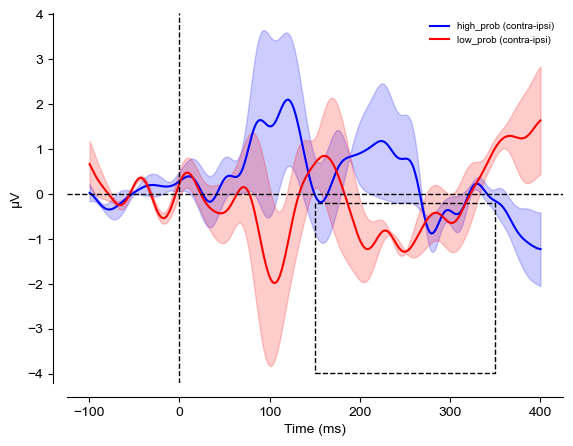

In [86]:
# Visualize group-level waveforms
print('Plotting group-level target-lateralized waveforms...')
plot_erp_timecourse(
    erp_data,
    times=times*1000,  # Convert to milliseconds
    elec_oi=[['PO3'], ['PO4']],  # Posterior lateral electrodes
    lateralized=True,
    cnds=['high_prob', 'low_prob'],
    colors=['blue', 'red'],
    show_SE=True,
    window_oi=(150, 350, 'neg'),  # Highlight N2pc window (150-350 ms)
    show_legend=True
)

print('\nWaveform shows contra-ipsi hemispheric differences.')

In [87]:
# Load group-level ERP data across all subjects
print('Loading group-level target-lateralized ERPs...')
erp_data, times = FolderStructure().read_erps(
    erp_name='target_lateralized',
    cnds=['absent', 'present'],
    sjs='all'
)

print(f'✓ Group data loaded successfully')
print(f'  • Conditions: {list(erp_data.keys())}')
print(f'  • Time points: {len(times)}')
print(f'  • Waveforms per condition: {[len(v) for v in erp_data.values()]}')
print(f'\nGroup-level waveforms ready for visualization and statistics')

Loading group-level target-lateralized ERPs...
✓ Group data loaded successfully
  • Conditions: ['absent', 'present']
  • Time points: 257
  • Waveforms per condition: [7, 7]

Group-level waveforms ready for visualization and statistics


Plotting group-level target-lateralized waveforms...
Data for condition 'absent' converted from volts to microvolts
bootstrapping using 9999 iterations
Data for condition 'present' converted from volts to microvolts
bootstrapping using 9999 iterations

Waveform shows contra-ipsi hemispheric differences.


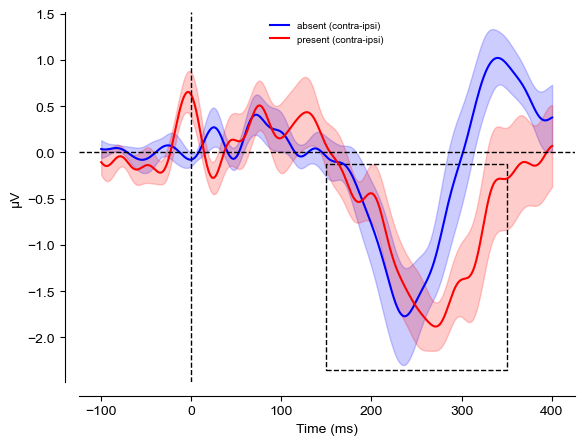

In [88]:
# Visualize group-level waveforms
print('Plotting group-level target-lateralized waveforms...')
plot_erp_timecourse(
    erp_data,
    times=times*1000,  # Convert to milliseconds
    elec_oi=[['PO3'], ['PO4']],  # Posterior lateral electrodes
    lateralized=True,
    cnds=['absent', 'present'],
    colors=['blue', 'red'],
    show_SE=True,
    window_oi=(150, 350, 'neg'),  # Highlight N2pc window (150-350 ms)
    show_legend=True
)

print('\nWaveform shows contra-ipsi hemispheric differences.')

In [95]:
sj

3

In [90]:
#Project setup
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Initialize FolderStructure
fs = FolderStructure()

# Load preprocessed data - select subject with lateral high-prob location
# Suitable subjects: 3 (high_prob at pos 6), 5 (high_prob at pos 2), 7 (high_prob at pos 6)
sj = 3  # Subject with high-prob at position 6

eye_dict = {
    'use_tracker': True,
    'window_oi': (0, 0.3),
    'angle_thresh': 1,
    'viewing_dist': 70,
    'screen_res': (1920, 1080),
    'screen_h': 29,
    'drift_correct': (-0.2, 0)
}

# Run distractor-lateralized analysis for suitable subjects (3, 5, 7)
print('Computing distractor-lateralized ERPs for subjects 3, 5, 7...')
for subject_id in [2,3,4,5,6,7]:
    # Load data for this subject
    df_sj, epochs_sj = FolderStructure().load_processed_epochs(
        subject_id, 'ses_01_main', 'main', eye_dict
    )
    
    # Initialize and analyze
    erp_sj = ERP(sj=subject_id, epochs=epochs_sj, df=df_sj,
                 baseline=(-0.1, 0), h_filter=30, l_filter=None,
                 laplacian=False, downsample=None, report=True)
    
    # Compute distractor-lateralized ERPs
    # Compute target-lateralized ERPs
    erp_sj.condition_erps(
        cnds=dict(target_cnd=['absent', 'present']),
        pos_labels=dict(dist_loc=[2, 6]),
        midline=dict(target_loc=[0, 4, 8]),
        topo_flip=dict(dist_loc=[2]),
        time_oi=(-0.1, 0.4),
        excl_factor=dict(block_type=['loc']),
        name='dist_lateralized'
    )
    print(f'  ✓ Subject {subject_id} complete')

print('\n✓ All subjects processed.')

Computing distractor-lateralized ERPs for subjects 3, 5, 7...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 20 columns
2902 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
4 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
Dropped 498 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband

ValueError: Number of evoked objects (0) must match number of captions (1)

In [ ]:
# Load group-level ERP data across all subjects
print('Loading group-level target-lateralized ERPs...')
erp_data, times = FolderStructure().read_erps(
    erp_name='target_lateralized',
    cnds=['absent', 'present'],
    sjs='all'
)

print(f'✓ Group data loaded successfully')
print(f'  • Conditions: {list(erp_data.keys())}')
print(f'  • Time points: {len(times)}')
print(f'  • Waveforms per condition: {[len(v) for v in erp_data.values()]}')
print(f'\nGroup-level waveforms ready for visualization and statistics')